# Euler-Maruyama Forward, SSCS backwards

--- Initializing Generalized Langevin Diffusion ---


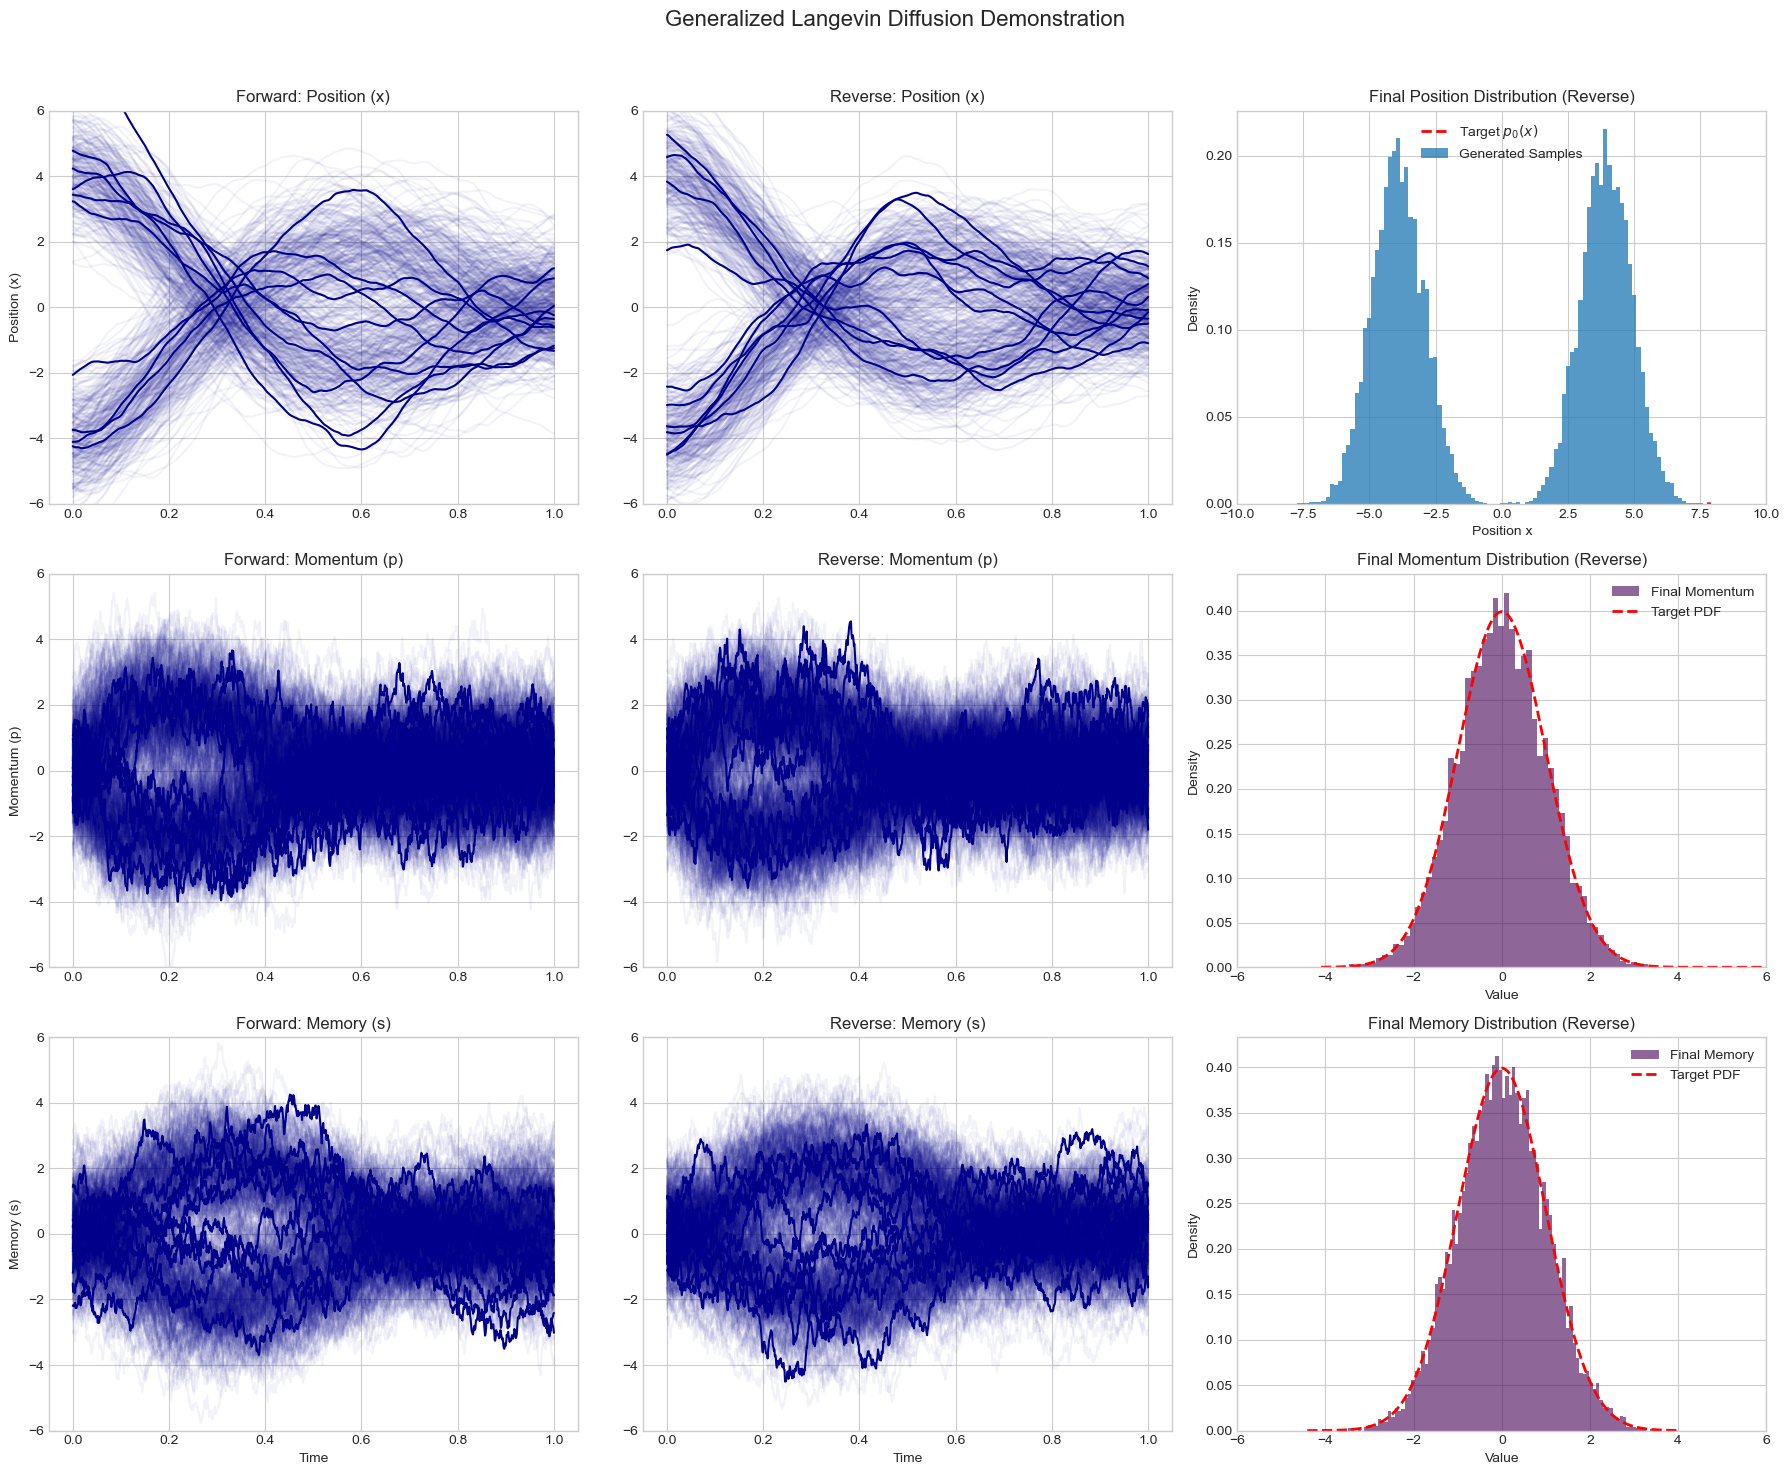

In [2]:
import torch
import math
from diffusion.cld import CriticallyDampedLangevin
from diffusion.gld import GeneralizedLangevinDiffusion
DEVICE = torch.device("cpu")

GMM_PARAMS = {
    'weights': [0.5, 0.5],
    'means': [-4., 4.],
    'stds': [1., 1.]
}
  # gamma = 1.0
n_plot, n_hist = 500, 10000
gld_model = GeneralizedLangevinDiffusion(GMM_PARAMS, inttype= 'sscs2', gamma=math.sqrt(2.0), lambda_val=1.0, c_val=0.9, M=1.0, n_steps=1000)
reverse_sde_paths = gld_model.run_demonstration(n_plot, n_hist)

# cld_model = CriticallyDampedLangevin(GMM_PARAMS)
# cld_model.run_demonstration(n_plot, n_hist)

--- Initializing Generalized Langevin Diffusion ---


/opt/anaconda3/lib/python3.11/site-packages/scipy/linalg/_solvers.py:193: RuntimeWarning: Input "a" has an eigenvalue pair whose sum is very close to or exactly zero. The solution is obtained via perturbing the coefficients.
  warnings.warn('Input "a" has an eigenvalue pair whose sum is '


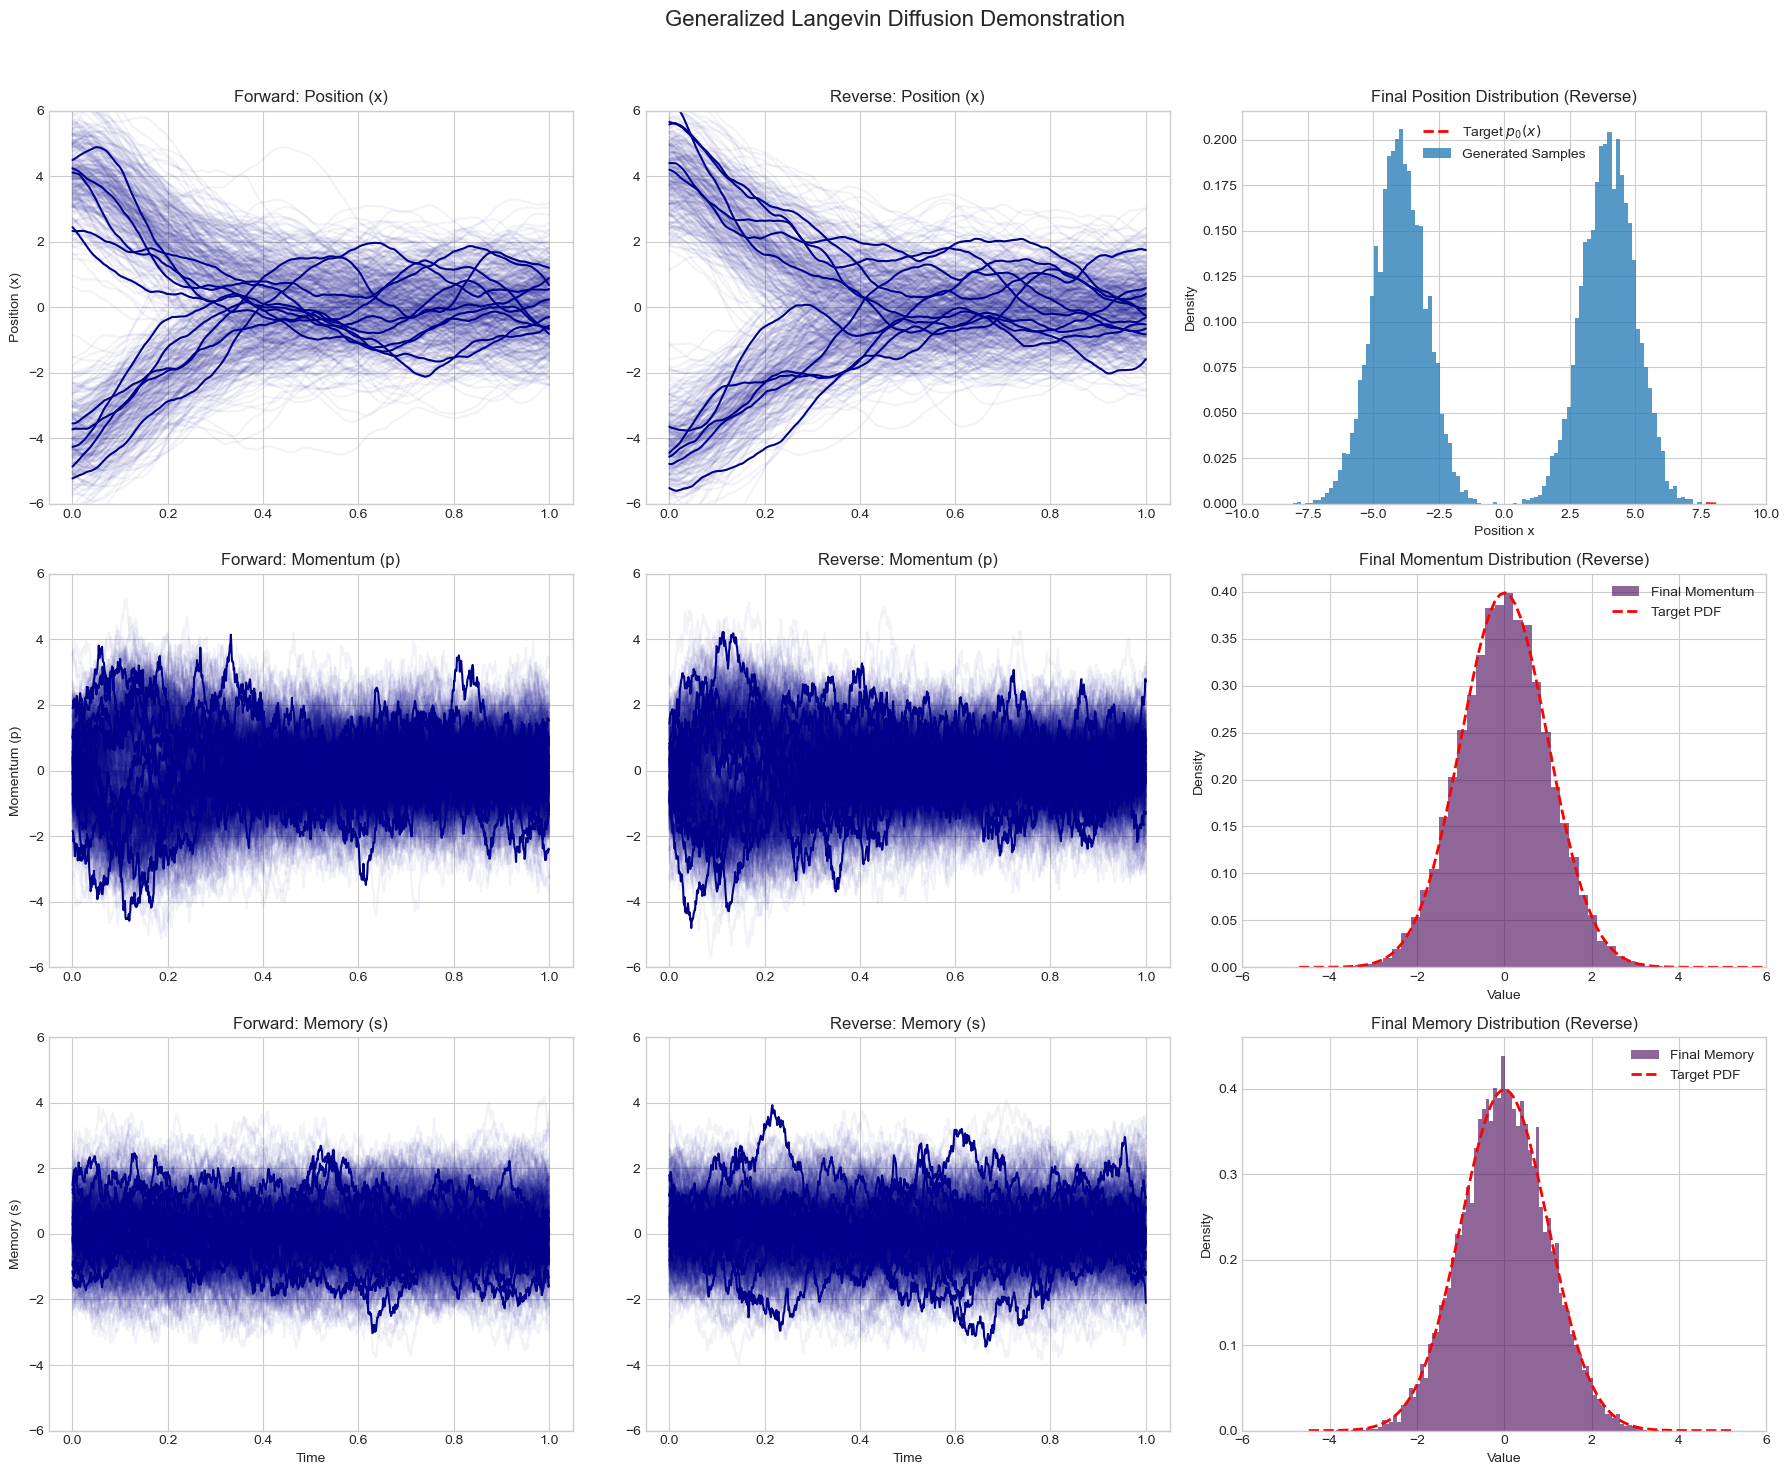

In [3]:
import torch
import numpy as np
import math
from diffusion.cld import CriticallyDampedLangevin
from diffusion.gld import GeneralizedLangevinDiffusion
DEVICE = torch.device("cpu")

GMM_PARAMS = {
    'weights': [0.5, 0.5],
    'means': [-4., 4.],
    'stds': [1., 1.]
}
  # gamma = 1.0
n_plot, n_hist = 500, 10000
gld_model = GeneralizedLangevinDiffusion(GMM_PARAMS, inttype= 'sscs', gamma=math.sqrt(2.0), lambda_val=1.0, c_val=0.0, M=1.0, n_steps=1000)
reverse_sde_paths = gld_model.run_demonstration(n_plot, n_hist)


print("A = " ,gld_model.A)
print("B = ", gld_model.B)
print("C = ", gld_model.C_np)
print("F = ", gld_model.F_half_np)
print("S = ", gld_model.S_half_np)
# print("exp_FO_half = ", gld_model.exp_FO_half)
print("dt = ", gld_model.dt)


In [4]:
import torch
import math
from diffusion.cld import CriticallyDampedLangevin
from diffusion.gld import GeneralizedLangevinDiffusion
DEVICE = torch.device("cpu")

GMM_PARAMS = {
    'weights': [0.5, 0.5],
    'means': [-40., 40.],
    'stds': [1., 1.]
}
  # gamma = 1.0
n_plot, n_hist = 500, 10000
gld_model = GeneralizedLangevinDiffusion(GMM_PARAMS, inttype= 'sscs2', gamma=2.0, lambda_val=1.0, c_val=0.0, n_steps=1000)


--- Initializing Generalized Langevin Diffusion ---


In [5]:
import scipy.linalg
from matrix_exp import stationary_covariance, compute_mean_and_covariance
scipy.linalg.sqrtm(gld_model.F_half_np)
A_np = gld_model.A.cpu().numpy()
G_np = gld_model.G.cpu().numpy()
C_np = stationary_covariance(gld_model.beta, gld_model.A_np, gld_model.G_np)
print("C_np = ", C_np)
#gld_model.F_half_np

# import scipy.linalg
# A_np = gld_model.A.cpu().numpy()
# G_np = gld_model.G.cpu().numpy()
# dt = gld_model.dt.item()
# F_np = scipy.linalg.expm(-gld_model.beta * A_np * dt/2)
        
# A_np = gld_model.A.numpy()
# dt = gld_model.dt.item()
# beta  = gld_model.beta
# scipy.linalg.expm(-beta * A_np * dt/2)


C_np =  [[ 1.0000001e+00 -6.3517007e-08  0.0000000e+00]
 [-7.9959307e-08  9.9999994e-01  0.0000000e+00]
 [ 0.0000000e+00  0.0000000e+00  1.0000000e+00]]


--- Initializing Critically Damped Langevin ---


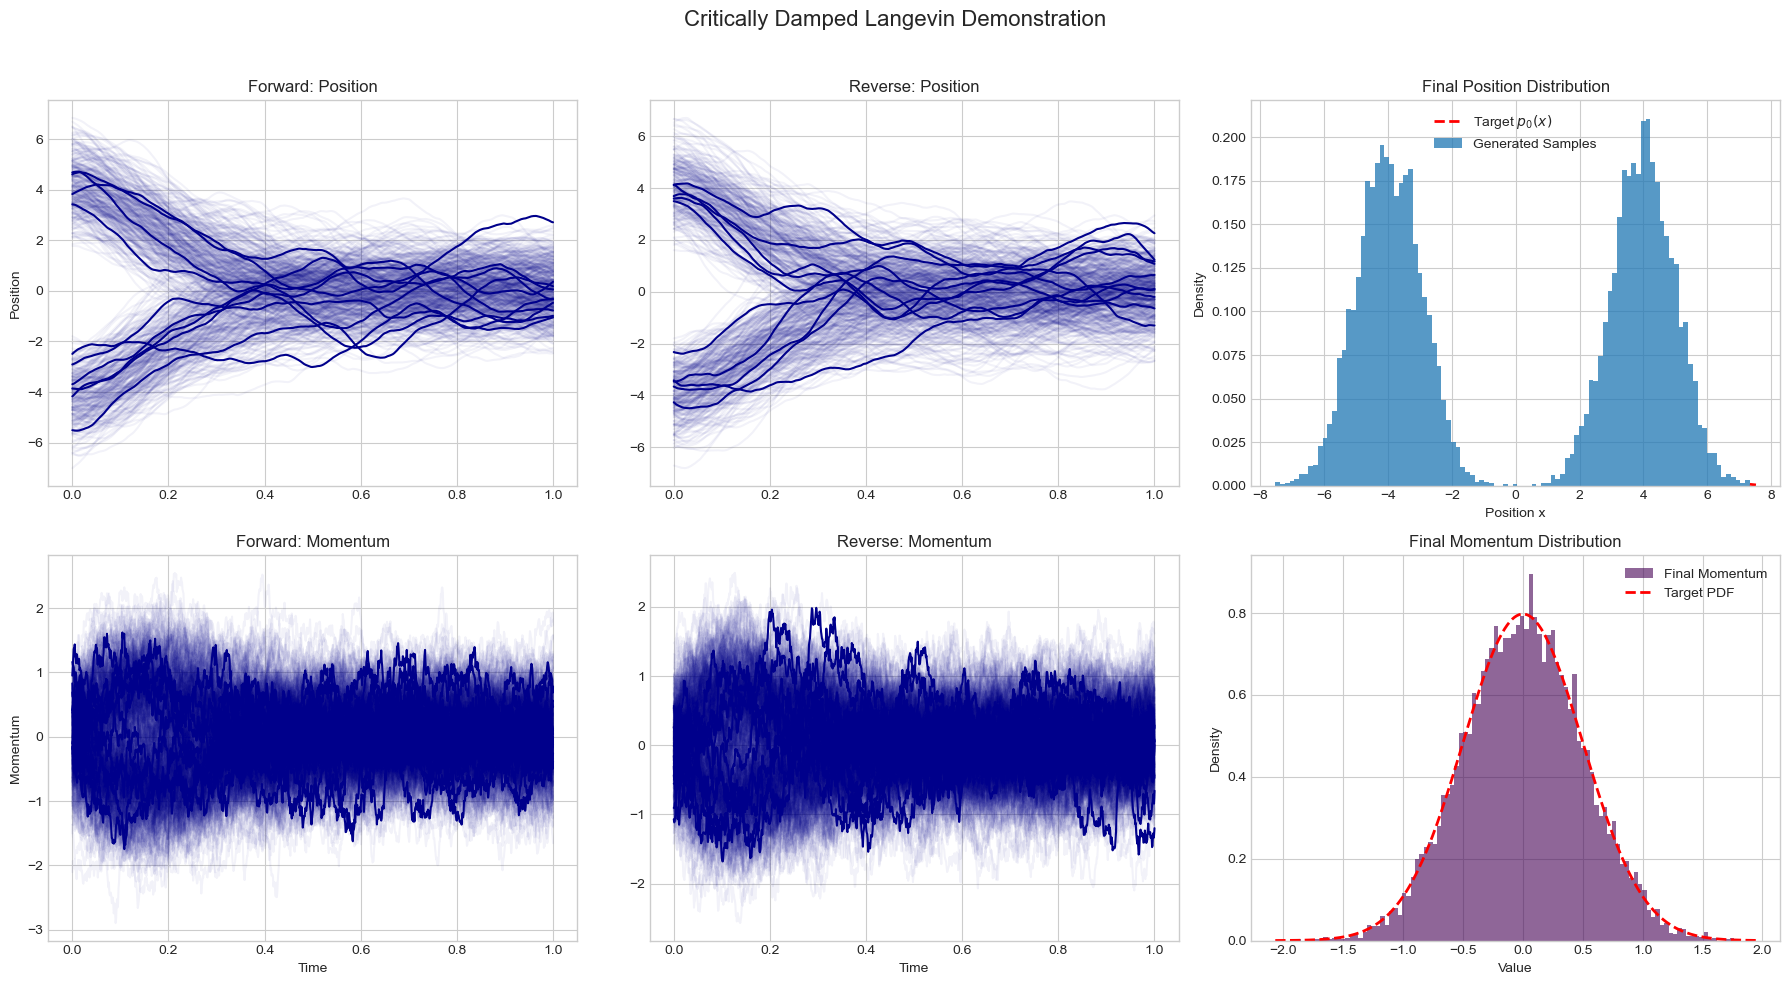

In [6]:
from diffusion.cld import CriticallyDampedLangevin
DEVICE = torch.device("cpu")

GMM_PARAMS = {
    'weights': [0.5, 0.5],
    'means': [-4., 4.],
    'stds': [1., 1.]
}
  # gamma = 1.0
n_plot, n_hist = 500, 10000
cld_model = CriticallyDampedLangevin(GMM_PARAMS, n_steps=1000)
cld_model.run_demonstration(n_plot, n_hist)

In [1]:
import os
import torch
import matplotlib.pyplot as plt
from diffusion.vpsde import VPSDE

GMM_PARAMS = {
    'weights': [0.5, 0.5],
    'means': [-4., 4.],
    'stds': [1., 1.]
}

# Train
vpsde = VPSDE(GMM_PARAMS)
model, losses = vpsde.train_score_network(n_epochs=1, batch_size=128)

# Save model
save_dir = "checkpoints/vpsde"
os.makedirs(save_dir, exist_ok=True)
torch.save(model.state_dict(), os.path.join(save_dir, "score_net_final.pt"))

# Save loss plot
plt.figure(figsize=(8,5))
plt.plot(range(1, len(losses)+1), losses, lw=2)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Score Network Training Loss")
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(save_dir, "training_loss.png"))
plt.close()


--- Initializing VP-SDE ---
Epoch 1/1 - Loss: 0.090460


In [ ]:
# import torch
# from models import ScoreNetwork

# DEVICE = torch.device("cpu")  # or "cuda" if you trained on GPU

# # Path to checkpoint
# checkpoint_path = "checkpoints/vpsde/score_net_final.pt"

# # Recreate the model and load weights
# model = ScoreNetwork().to(DEVICE)
# model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
# model.eval()

# print("Model successfully loaded from checkpoint.")
n_plot, n_hist = 500, 10000
model.eval()
vpsde.run_demonstration(n_plot, n_hist, score_model=model)

RuntimeError: expand(torch.FloatTensor{[10000, 10000]}, size=[10000]): the number of sizes provided (1) must be greater or equal to the number of dimensions in the tensor (2)